# LSTM for Predicting Mouse Decisions from Steinmetz LFP Data

This notebook loads preprocessed LFP data from the Steinmetz dataset (in the format generated by `steinmetz_NMA.ipynb`), specifically focusing on the VISp brain region during the 500ms to 1000ms time window *post-stimulus onset*. We will then train an LSTM model to predict the mouse's decision (left, right, or no-go).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import requests 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
import random

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

# It's also good practice to set an environment variable for TensorFlow
# to ensure more deterministic operations on GPUs, though it might have a performance cost.
# os.environ['TF_DETERMINISTIC_OPS'] = '1' # Uncomment if using TensorFlow with GPU and need strict determinism

print(f"Seeds set to {SEED}")

In [2]:
# --- Configuration ---
# IMPORTANT: Adjust this path to the directory where NPZ files will be downloaded/stored.
PROCESSED_DATA_DIR = os.path.join(os.getcwd(), 'steinmetz_data_downloads') 
# Ensure the directory exists (the download cell will also try to create it)
os.makedirs(PROCESSED_DATA_DIR, exist_ok=True)
print(f"Data will be downloaded/loaded from: {PROCESSED_DATA_DIR}")

Data will be downloaded/loaded from: /Volumes/SSD/IMPACT SCHOLAR SUBMISSION 1/neural_navigators-main/notebooks/steinmetz_data_downloads


In [3]:
SESSION_INDEX = 0 # Which session to analyze from the loaded data (after aggregating all .npz files)
TARGET_BRAIN_REGION = 'VISp'

# Time window for LFP data, relative to stimulus onset
TIME_WINDOW_START_POST_STIM_MS = 500
TIME_WINDOW_END_POST_STIM_MS = 1000


In [4]:
# LSTM Hyperparameters
N_EPOCHS = 50
BATCH_SIZE = 32
LSTM_UNITS_1 = 64
LSTM_UNITS_2 = 32
DENSE_UNITS = 32
DROPOUT_RATE = 0.3

## 1. Data Download and Loading

This section handles the download and loading of the Steinmetz dataset components:
- **Main data parts (`steinmetz_part0.npz`, `steinmetz_part1.npz`, `steinmetz_part2.npz`):** These files contain spiking activity, behavioral information, trial timings, etc. They are downloaded from the standard OSF links commonly used in Neuromatch Academy tutorials.
- **LFP data (`steinmetz_lfp.npz`):** This file contains the Local Field Potential (LFP) data and corresponding brain area information. It is downloaded from a specific OSF link (`https://osf.io/kx3v9/download`) known to provide this LFP-specific dataset.

Both sets of data are loaded, and the data for the `SESSION_INDEX` specified in the configuration is extracted for further processing.

In [5]:
# Ensure 'requests' and 'numpy' are imported in an earlier cell.
# This cell handles data download and loading.

# --- Configuration for OSF download ---
# PROCESSED_DATA_DIR should be defined in a previous cell.
# If not, this cell will attempt to create a default one.
try:
    target_dir = PROCESSED_DATA_DIR
    if not os.path.isdir(target_dir):
        print(f"Warning: PROCESSED_DATA_DIR '{target_dir}' does not exist. Creating it.")
        os.makedirs(target_dir, exist_ok=True)
except NameError:
    print("PROCESSED_DATA_DIR not defined in a previous cell. Defaulting to a subdirectory 'steinmetz_data_downloads' in current working directory.")
    target_dir = os.path.join(os.getcwd(), 'steinmetz_data_downloads')
    os.makedirs(target_dir, exist_ok=True)
    PROCESSED_DATA_DIR = target_dir # Define it globally if it wasn't

# --- Download Files ---
fname_parts_download = []
for j in range(3):
    fname_parts_download.append(os.path.join(target_dir, 'steinmetz_part%d.npz' % j))

urls_parts_download = [
    "https://osf.io/agvxh/download",
    "https://osf.io/uv3mw/download",
    "https://osf.io/ehmw2/download",
]

fname_lfp_download = os.path.join(target_dir, 'steinmetz_lfp.npz')
url_lfp_download = "https://osf.io/kx3v9/download"

all_fnames_to_download = fname_parts_download + [fname_lfp_download]
all_urls_to_download = urls_parts_download + [url_lfp_download]

print("Starting download process...")
for i in range(len(all_fnames_to_download)):
    fname_current = all_fnames_to_download[i]
    url_current = all_urls_to_download[i]
    
    # Basic check for existing files to avoid re-download if not necessary
    if os.path.isfile(fname_current):
        file_size_mb_check = os.path.getsize(fname_current) / (1024 * 1024)
        is_lfp_file_check = "steinmetz_lfp.npz" in fname_current
        is_part_file_check = "steinmetz_part" in fname_current

        if is_lfp_file_check and file_size_mb_check > 10: # Expect LFP file > 10mb/1GB
             print(f"File {os.path.basename(fname_current)} already exists and seems complete (Size: {file_size_mb_check:.2f} MB). Skipping download.")
             continue
        elif is_part_file_check and file_size_mb_check > 10: # Expect part files > 10mb/50MB
             print(f"File {os.path.basename(fname_current)} already exists and seems complete (Size: {file_size_mb_check:.2f} MB). Skipping download.")
             continue
        elif os.path.isfile(fname_current): # File exists but is too small or not recognized type for size check
            print(f"File {os.path.basename(fname_current)} exists (Size: {file_size_mb_check:.2f} MB), but might be incomplete or is not a main/LFP part for size check. Re-downloading.")


    print(f"Downloading {os.path.basename(fname_current)} from {url_current}...")
    try:
        r = requests.get(url_current, timeout=300) # 5 min timeout for potentially large files
        r.raise_for_status()
    except requests.ConnectionError:
        print(f"!!! Failed to connect to {url_current} for file {os.path.basename(fname_current)} !!!")
        print("Please check your internet connection. Skipping this file.")
        continue
    except requests.exceptions.Timeout:
        print(f"!!! Timeout while downloading {os.path.basename(fname_current)} from {url_current} !!! Skipping this file.")
        continue
    except requests.exceptions.RequestException as e:
        print(f"!!! Failed to download {os.path.basename(fname_current)} from {url_current}: {e} !!!")
        print(f"Warning: Skipping {os.path.basename(fname_current)} due to download failure.")
        continue
    else:
        with open(fname_current, "wb") as fid:
            fid.write(r.content)
        file_size_mb = os.path.getsize(fname_current) / (1024 * 1024)
        print(f"Successfully downloaded {os.path.basename(fname_current)}. Size: {file_size_mb:.2f} MB")
print("Download process complete.")

# --- Load Main Data (Spikes, Behavior, etc.) ---
alldat_main_list = []
main_npz_files_to_load = [os.path.join(target_dir, 'steinmetz_part%d.npz' % j) for j in range(3)]

print(f"\nLoading main data (steinmetz_part*.npz files) from {target_dir}:")
for f_path in main_npz_files_to_load:
    f_name = os.path.basename(f_path)
    if not os.path.isfile(f_path):
        print(f"Error: Main data file {f_name} not found in {target_dir}. Halting.")
        raise FileNotFoundError(f"Required main data file {f_name} is missing. Cannot proceed.")
    print(f"  - Loading {f_name}...")
    try:
        data_part = np.load(f_path, allow_pickle=True)
        if 'dat' in data_part and isinstance(data_part['dat'], (list, np.ndarray)):
            alldat_main_list.extend(data_part['dat'])
        else:
            print(f"Warning: File {f_name} does not contain a 'dat' key, or 'dat' is not a list/array.")
            print(f"         Available keys in {f_name}: {list(data_part.keys()) if isinstance(data_part, np.lib.npyio.NpzFile) else 'Not an NpzFile'}")
            raise ValueError(f"File {f_name} has unexpected structure. Cannot extract session data.")
    except Exception as e:
        print(f"Critical error loading {f_name}: {e}")
        raise

if not alldat_main_list:
    raise ValueError("No main session data (spikes/behavior) could be loaded. Check downloads and PROCESSED_DATA_DIR.")
print(f"Successfully loaded main data for {len(alldat_main_list)} sessions.")

# --- Load LFP Data ---
lfp_file_path_load = os.path.join(target_dir, 'steinmetz_lfp.npz')
if not os.path.isfile(lfp_file_path_load):
    raise FileNotFoundError(f"'steinmetz_lfp.npz' not found in {target_dir}. Please ensure it was downloaded correctly.")

print(f"\nLoading LFP data from: {os.path.basename(lfp_file_path_load)}...")
try:
    dat_LFP_all_sessions = np.load(lfp_file_path_load, allow_pickle=True)['dat']
    print(f"Successfully loaded LFP data for {len(dat_LFP_all_sessions)} sessions.")
except Exception as e:
    raise ValueError(f"Error loading 'steinmetz_lfp.npz': {e}")

# --- Select Session and Combine Data ---
if SESSION_INDEX >= len(alldat_main_list) or SESSION_INDEX >= len(dat_LFP_all_sessions):
    raise IndexError(
        f"SESSION_INDEX ({SESSION_INDEX}) is out of bounds. "
        f"Number of main sessions: {len(alldat_main_list)}, Number of LFP sessions: {len(dat_LFP_all_sessions)}."
    )

session_data_main = alldat_main_list[SESSION_INDEX]
session_data_lfp = dat_LFP_all_sessions[SESSION_INDEX]

print(f"\nUsing session {SESSION_INDEX}:")
print(f"  Mouse (from main data): {session_data_main.get('mouse_name', 'N/A')}, Date: {session_data_main.get('date_exp', 'N/A')}")

# --- Extract data for the LSTM ---
required_lfp_keys = ['lfp', 'brain_area_lfp']
missing_lfp_keys = [key for key in required_lfp_keys if key not in session_data_lfp]
if missing_lfp_keys:
    raise KeyError(f"The selected LFP session (index {SESSION_INDEX}) is missing essential LFP data keys: {missing_lfp_keys}. Available LFP keys: {list(session_data_lfp.keys())}")

lfp_data_full_trial = session_data_lfp['lfp']
lfp_brain_areas_list = session_data_lfp['brain_area_lfp'] # This is likely a list of strings

required_main_keys = ['response', 'bin_size', 'stim_onset']
missing_main_keys = [key for key in required_main_keys if key not in session_data_main]
if missing_main_keys:
    raise KeyError(f"The selected main session (index {SESSION_INDEX}) is missing essential data keys: {missing_main_keys}. Available main keys: {list(session_data_main.keys())}")

responses_orig = session_data_main['response']
dt_s = session_data_main['bin_size']
stim_onset_s = session_data_main['stim_onset']

print(f"LFP data shape (channels, trials, timebins): {lfp_data_full_trial.shape}")

if isinstance(lfp_brain_areas_list, list):
    print(f"LFP brain areas (list of regions, {len(lfp_brain_areas_list)} channels): {lfp_brain_areas_list}")
    lfp_brain_areas = np.array(lfp_brain_areas_list) 
elif isinstance(lfp_brain_areas_list, np.ndarray):
    print(f"LFP brain areas (numpy array, shape {lfp_brain_areas_list.shape}): {lfp_brain_areas_list}")
    lfp_brain_areas = lfp_brain_areas_list
else:
    print(f"Warning: lfp_brain_areas is of unexpected type: {type(lfp_brain_areas_list)}. Content: {lfp_brain_areas_list}")
    lfp_brain_areas = np.array(lfp_brain_areas_list) # Attempt conversion

print(f"Responses shape: {responses_orig.shape}")
print(f"LFP time bin size (dt): {dt_s} s")
print(f"Stimulus onset time within LFP data (T0): {stim_onset_s} s")

Starting download process...
File steinmetz_part0.npz already exists and seems complete (Size: 83.49 MB). Skipping download.
File steinmetz_part1.npz already exists and seems complete (Size: 67.14 MB). Skipping download.
File steinmetz_part2.npz already exists and seems complete (Size: 61.13 MB). Skipping download.
File steinmetz_lfp.npz already exists and seems complete (Size: 150.36 MB). Skipping download.
Download process complete.

Loading main data (steinmetz_part*.npz files) from /Volumes/SSD/IMPACT SCHOLAR SUBMISSION 1/neural_navigators-main/notebooks/steinmetz_data_downloads:
  - Loading steinmetz_part0.npz...
  - Loading steinmetz_part1.npz...
  - Loading steinmetz_part2.npz...
Successfully loaded main data for 39 sessions.

Loading LFP data from: steinmetz_lfp.npz...
Successfully loaded LFP data for 39 sessions.

Using session 0:
  Mouse (from main data): Cori, Date: 2016-12-14
LFP data shape (channels, trials, timebins): (7, 214, 250)
LFP brain areas (list of regions, 7 chan

## 2. Data Preprocessing for LSTM

- Select LFP channels from the target brain region (VISp).
- Extract the LFP data for the specified time window post-stimulus onset.
- Normalize the LFP data.
- Reshape LFP data for LSTM input: `(n_trials, n_timesteps_in_window, n_visp_channels)`
- Encode behavioral responses for classification.

In [6]:
# --- Select VISp LFP Channels ---
visp_channel_indices = np.where(lfp_brain_areas == TARGET_BRAIN_REGION)[0]
if len(visp_channel_indices) == 0:
    available_regions = np.unique(lfp_brain_areas)
    raise ValueError(f"No LFP channels found for brain region '{TARGET_BRAIN_REGION}'. \n"
                     f"Available regions in this session: {available_regions}. \n"
                     f"Please check TARGET_BRAIN_REGION or the data for session {SESSION_INDEX}.")
print(f"Found {len(visp_channel_indices)} LFP channels for {TARGET_BRAIN_REGION}.")
lfp_visp_full_trial = lfp_data_full_trial[visp_channel_indices, :, :] # (n_visp_channels, n_trials, n_timebins_total_trial)

# --- Determine Time Window Indices Post-Stimulus Onset ---
t_start_post_stim_s = TIME_WINDOW_START_POST_STIM_MS / 1000.0
t_end_post_stim_s = TIME_WINDOW_END_POST_STIM_MS / 1000.0

# Calculate start and end times relative to the beginning of the LFP trial data
lfp_window_start_s_abs = stim_onset_s + t_start_post_stim_s
lfp_window_end_s_abs = stim_onset_s + t_end_post_stim_s

# Convert these times to indices
start_idx = int(np.round(lfp_window_start_s_abs / dt_s))
end_idx = int(np.round(lfp_window_end_s_abs / dt_s))

# Validate indices
total_timebins_in_trial = lfp_visp_full_trial.shape[2]
if start_idx < 0 or end_idx > total_timebins_in_trial or start_idx >= end_idx:
    raise ValueError(f"Calculated LFP window indices [{start_idx}:{end_idx}] are invalid for total timebins {total_timebins_in_trial}.\n"
                         f"  LFP snippet duration: {total_timebins_in_trial * dt_s:.2f}s.\n"
                         f"  Stimulus onset (T0): {stim_onset_s:.2f}s (index ~{int(stim_onset_s/dt_s)}).\n"
                         f"  Target window post-stim: {t_start_post_stim_s:.2f}s to {t_end_post_stim_s:.2f}s.\n"
                         f"  Absolute window in LFP: {lfp_window_start_s_abs:.2f}s to {lfp_window_end_s_abs:.2f}s.\n"
                         f"  Check TIME_WINDOW settings, dt ({dt_s:.3f}s), and stim_onset ({stim_onset_s:.2f}s).")

print(f"Extracting LFP from time {lfp_window_start_s_abs:.3f}s to {lfp_window_end_s_abs:.3f}s (indices {start_idx} to {end_idx-1}) relative to LFP data start.")
print(f"This corresponds to {t_start_post_stim_s:.3f}s to {t_end_post_stim_s:.3f}s post-stimulus onset.")
num_timesteps_in_window = end_idx - start_idx
print(f"Number of LFP timebins in window: {num_timesteps_in_window}")

if num_timesteps_in_window <= 0:
    raise ValueError("The calculated time window has zero or negative duration. Please check parameters.")

# Segment LFP data for the window: (n_visp_channels, n_trials, n_timesteps_in_window)
lfp_visp_windowed = lfp_visp_full_trial[:, :, start_idx:end_idx]

# Transpose for LSTM: (n_trials, n_timesteps_in_window, n_visp_channels)
X_data = np.transpose(lfp_visp_windowed, (1, 2, 0))
print(f"Shape of X_data before scaling (trials, timesteps, features): {X_data.shape}")

if X_data.shape[0] == 0 or X_data.shape[1] == 0 or X_data.shape[2] == 0:
    raise ValueError(f"LFP data for LSTM is empty after processing: {X_data.shape}. Check data and parameters.")

# --- Scale LFP Data ---
n_trials, _, n_features = X_data.shape
# Reshape for scaling: each feature (channel) scaled across all trials and timesteps
X_data_reshaped = X_data.reshape(-1, n_features)
scaler = StandardScaler()
X_scaled_reshaped = scaler.fit_transform(X_data_reshaped)
X = X_scaled_reshaped.reshape(n_trials, num_timesteps_in_window, n_features) # Reshape back
print(f"Shape of X after scaling: {X.shape}")

# --- Prepare Labels (Responses) ---
# Map responses: -1 (Left) to 0, 0 (No-go) to 1, 1 (Right) to 2
y_mapped = np.zeros_like(responses_orig, dtype=int)
y_mapped[responses_orig == -1] = 0 # Left
y_mapped[responses_orig == 0]  = 1 # No-go
y_mapped[responses_orig == 1]  = 2 # Right

# One-hot encode labels
encoder = OneHotEncoder(sparse_output=False)
y = encoder.fit_transform(y_mapped.reshape(-1, 1))
print(f"Shape of y (one-hot encoded responses): {y.shape}")
print(f"Original response values: {np.unique(responses_orig)}")
print(f"Mapped response values: {np.unique(y_mapped)}")
print(f"Example responses: Original={responses_orig[0]}, Mapped={y_mapped[0]}, One-hot={y[0]}")

Found 1 LFP channels for VISp.
Extracting LFP from time 1.000s to 1.500s (indices 100 to 149) relative to LFP data start.
This corresponds to 0.500s to 1.000s post-stimulus onset.
Number of LFP timebins in window: 50
Shape of X_data before scaling (trials, timesteps, features): (214, 50, 1)
Shape of X after scaling: (214, 50, 1)
Shape of y (one-hot encoded responses): (214, 3)
Original response values: [-1.  0.  1.]
Mapped response values: [0 1 2]
Example responses: Original=1.0, Mapped=2, One-hot=[0. 0. 1.]


## 3. Split Data into Training and Testing Sets

In [7]:
if X.shape[0] == 0 or y.shape[0] == 0:
    raise ValueError("Input data X or labels y are empty. Cannot proceed with train/test split.")
if X.shape[0] != y.shape[0]:
    raise ValueError(f"Mismatch in number of samples: X has {X.shape[0]} and y has {y.shape[0]}.")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y_mapped # Stratify by mapped labels before one-hot
)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (171, 50, 1), y_train shape: (171, 3)
X_test shape: (43, 50, 1), y_test shape: (43, 3)


## 4. Build and Train LSTM Model

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 50, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 50, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_dense (Dense)            │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,851 (120.51 KB)

 Trainable params: 30,659 (119.76 KB)

 Non-trainable params: 192 (768.00 B)


Training the model...
Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.3436 - loss: 1.5307 - val_accuracy: 0.5429 - val_loss: 1.0945
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3312 - loss: 1.3446 - val_accuracy: 0.6000 - val_loss: 1.0900
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4347 - loss: 1.3316 - val_accuracy: 0.4571 - val_loss: 1.0901
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4090 - loss: 1.2624 - val_accuracy: 0.5143 - val_loss: 1.0853
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5191 - loss: 1.0220 - val_accuracy: 0.5143 - val_loss: 1.0796
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4412 - loss: 1.3738 - val_accuracy: 0.4857 - val_loss: 1.0732
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4586 - loss: 1.1601 - val_accuracy: 0.5143 - val_loss: 1.0750
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4441 - loss: 1.1114 - val_accuracy: 0.4

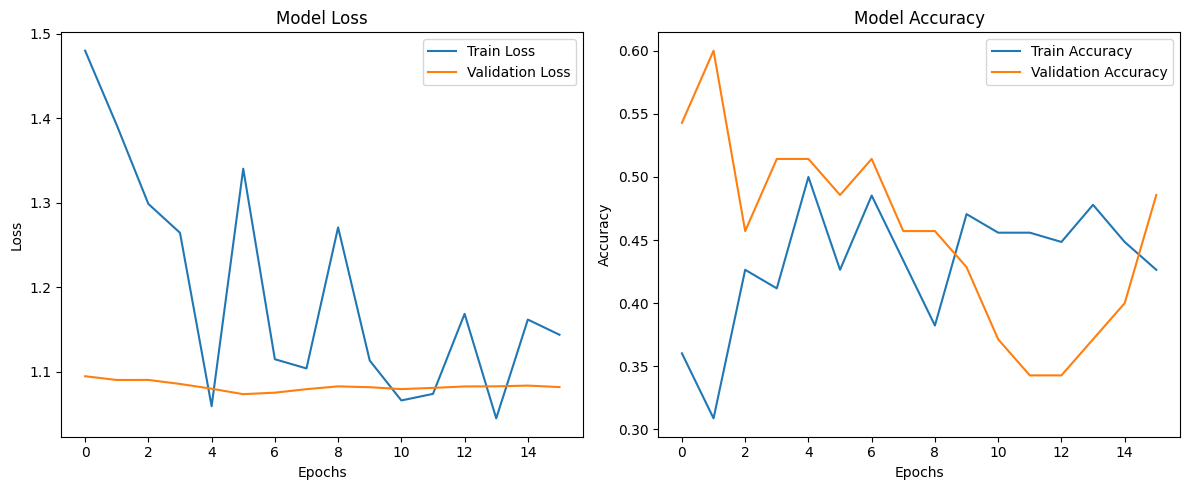

In [8]:
# Cell 9
if X_train.size == 0:
    print("Training data is empty. Skipping model definition and training.")
else:
    input_shape = (X_train.shape[1], X_train.shape[2]) # (n_timesteps, n_features)
    num_classes = y_train.shape[1]

    model = Sequential([
        tf.keras.Input(shape=input_shape, name='input_layer'), # MODIFIED: Explicit Input layer
        LSTM(LSTM_UNITS_1, return_sequences=True, name='lstm_1'), # MODIFIED: Removed input_shape from here
        BatchNormalization(name='bn_1'),
        Dropout(DROPOUT_RATE, name='dropout_1'),
        LSTM(LSTM_UNITS_2, return_sequences=False, name='lstm_2'),
        BatchNormalization(name='bn_2'),
        Dropout(DROPOUT_RATE, name='dropout_2'),
        Dense(DENSE_UNITS, activation='relu', name='dense_1'),
        Dropout(DROPOUT_RATE, name='dropout_3'),
        Dense(num_classes, activation='softmax', name='output_dense')
    ])

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    model.summary()

    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    print("\nTraining the model...")
    history = model.fit(X_train, y_train,
                        epochs=N_EPOCHS,
                        batch_size=BATCH_SIZE,
                        validation_split=0.2, # Use part of training data for validation
                        callbacks=[early_stopping],
                        verbose=1)

    # Plot training history
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.tight_layout()
    plt.show()

## 5. Evaluate Model Performance


Test Loss: 1.0871
Test Accuracy: 0.3953
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step

Classification Report:
                          precision    recall  f1-score   support

Left (orig -1, mapped 0)       0.67      0.14      0.24        14
No-go (orig 0, mapped 1)       0.34      0.67      0.45        15
Right (orig 1, mapped 2)       0.45      0.36      0.40        14

                accuracy                           0.40        43
               macro avg       0.49      0.39      0.36        43
            weighted avg       0.49      0.40      0.37        43



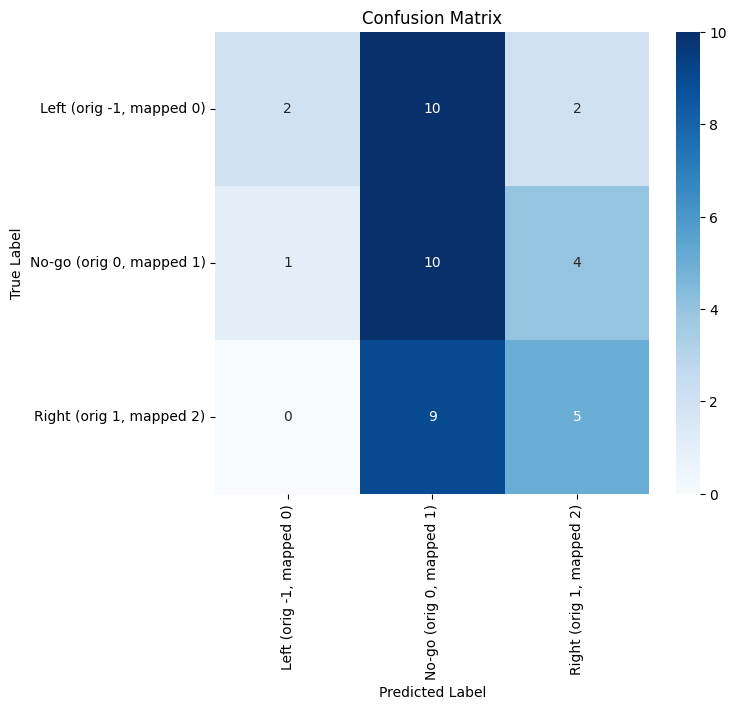

In [9]:
if 'model' not in globals() or X_test.size == 0:
    print("Skipping model evaluation: Model not trained or test data is empty.")
else:
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
    print(f"\nTest Loss: {loss:.4f}")
    print(f"Test Accuracy: {accuracy:.4f}")

    y_pred_proba = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred_proba, axis=1)
    y_true_classes = np.argmax(y_test, axis=1) # Convert one-hot back to class labels

    # Original labels: -1 (Left mapped to 0), 0 (No-go mapped to 1), 1 (Right mapped to 2)
    class_names_report = ['Left (orig -1, mapped 0)', 'No-go (orig 0, mapped 1)', 'Right (orig 1, mapped 2)']
    print("\nClassification Report:")
    print(classification_report(y_true_classes, y_pred_classes, target_names=class_names_report, zero_division=0))

    cm = confusion_matrix(y_true_classes, y_pred_classes)
    try:
        import seaborn as sns
        plt.figure(figsize=(7,6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=class_names_report, yticklabels=class_names_report)
        plt.title('Confusion Matrix')
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.show()
    except ImportError:
        print("Seaborn not installed. Skipping confusion matrix heatmap. Confusion Matrix array:")
        print(cm)

## 6. Conclusion

This notebook demonstrated loading preprocessed Steinmetz LFP data, focusing on the VISp region and a specific post-stimulus time window, and then training an LSTM model to predict mouse decisions. The model's performance on the test set gives an initial indication of its predictive capability. 

Potential next steps for improvement:
- Hyperparameter tuning (LSTM units, dropout rates, batch size, learning rate).
- Trying different LFP preprocessing techniques (e.g., different frequency bands, power spectral density features).
- Exploring different model architectures (e.g., CNN-LSTM, attention mechanisms).
- Analyzing data from more brain regions or combining data from multiple sessions/mice.
- More sophisticated handling of class imbalance if present.